In [1]:
import torch
from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms

%load_ext autoreload
%autoreload 2

In [5]:
# /home/jovyan/.mlspace/envs/genimages

### Testing Model

In [10]:
config = OmegaConf.load('configs/train_config_vit.yaml')

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [12]:
model = ImageTransformPredictor(config.model)

In [13]:
# checkpoint_path = 'checkpoints/itp_008/checkpoint_epoch_20.pth' # хороший чекпоинт в 008
# checkpoint_path = 'checkpoints/itp_009/checkpoint_epoch_.pth'

# checkpoint = torch.load(checkpoint_path, map_location='cpu')
# model.load_state_dict(checkpoint['model_state_dict'])
# model.to('cpu')
model.eval()
print('ready')

ready


['horizontal_flip', 'rotate_90', 'vertical_flip', 'grayscale', 'noise_adding']


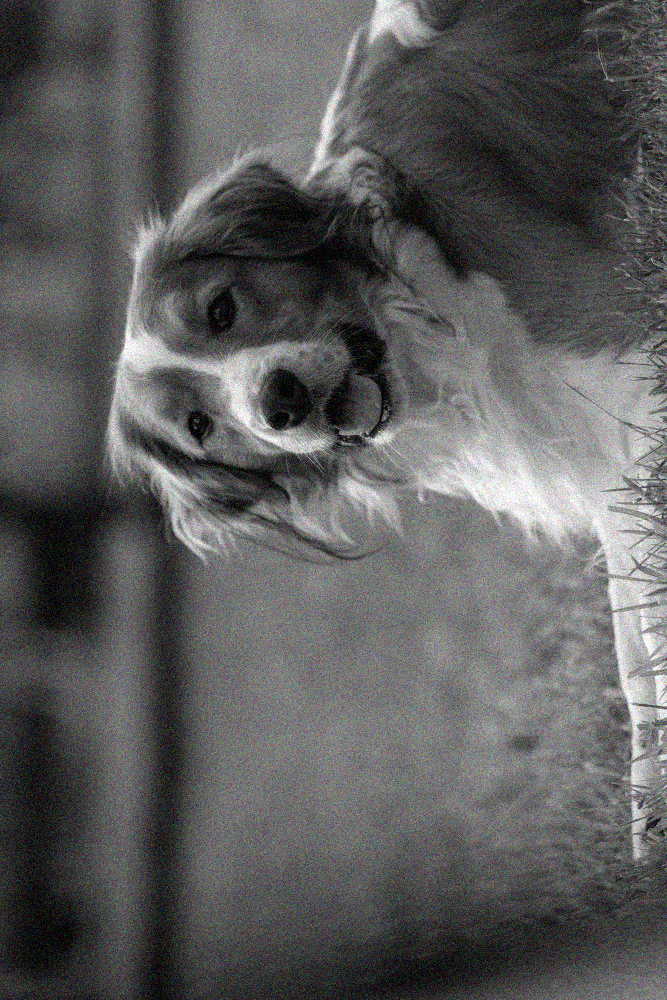

In [14]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, 0.3)
print(sequence_1)
transformed_image_1

In [15]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['horizontal_flip', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts', 'jpeg_artefacts']
Target: ['horizontal_flip', 'rotate_90', 'vertical_flip', 'grayscale', 'noise_adding']


### New Decoder

In [46]:
config = OmegaConf.load('configs/train_config_rope.yaml')

In [47]:
encoder = ImagePairEncoder(config.model.encoder)

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

encoder.eval()
with torch.no_grad():
    test_images1 = torch.randn(1, 3, 224, 224)
    test_images2 = torch.randn(1, 3, 224, 224)
    embs = encoder(test_images1, test_images2)
embs.shape

Loaded pretrained weights for efficientnet-b3


torch.Size([1, 512])

In [51]:
decoder = TransformDecoderRope(config.model.decoder)

decoder.eval()
with torch.no_grad():
    seq = decoder.generate(embs, max_new_tokens=14, do_sample=True)
seq.shape
print(seq)

tensor([[ 1, 12, 11,  8,  8,  8, 11, 12, 13, 13, 12, 11,  3, 12, 11]])


### ViT Encoder

In [16]:
from src.model.vit_encoder import FlexibleViTEncoder, ImagePairViT

In [17]:
config = OmegaConf.load('configs/train_config_vit.yaml')

In [18]:
config.model.encoder

{'type': 'vit', 'n_embd': 512, 'patch_size': 14, 'n_layer': 3, 'n_head': 8, 'ffn_ratio': 4, 'dropout': 0.1, 'activation': 'gelu', 'use_cls_token': False, 'final_norm': True}

In [23]:
encoder = FlexibleViTEncoder(config.model.encoder)

In [22]:
model = ImagePairViT(config.model.encoder)

# Важно: H и W должны делиться на patch_size=14
B, C, H, W = 2, 3, 224, 224  # 224 % 14 == 0

image_batch_1 = torch.randn(B, C, H, W)
image_batch_2 = torch.randn(B, C, H, W)

# Прямой проход
with torch.no_grad():
    output = model(image_batch_1, image_batch_2)

# Проверяем форму выхода
print("Input shape:", image_batch_1.shape)   # [2, 3, 224, 224]
print("Output shape:", output.shape)        # [2, N1 + 1 + N2, 512]

# Для 224x224 и patch_size=14: N = (224//14)^2 = 16*16 = 256
# Значит: N1 = 256, N2 = 256, total = 256 + 1 + 256 = 513
expected_seq_len = (224 // 14) ** 2 * 2 + 1  # 513
print("Expected sequence length:", expected_seq_len)
assert output.shape == (B, expected_seq_len, 512), "Shape mismatch!"

Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 513, 512])
Expected sequence length: 513
